# 1. Imports

In [29]:
from pathlib import Path
from src.io import build_dataframes
from src.cleaning import clean_metadata
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import contextily as ctx
from adjustText import adjust_text

plt.rcParams['image.cmap'] = 'inferno'

inferno = cm.get_cmap('inferno')
colors = [inferno(i) for i in [0.2, 0.4, 0.6, 0.8]]

/var/folders/w_/v957zs393c5dg1q6n0kpt_pr0000gn/T/ipykernel_3069/1544532172.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap('inferno')


# 2. Data loading

In [3]:
zip_path = Path("..") / "data" / "raw" / "query.zip"
df_meta, df_acc = build_dataframes(zip_path)

# 3. Metadata exploration

In [8]:
# Shape
print("Metadata DataFrame shape:", df_meta.shape)

# Columns
print("\nMetadata columns:")
for col in df_meta.columns:
    print(f"  {col}")

# Data types
print("\nColumn types distribution:")
print(df_meta.dtypes.value_counts())

# Missing values
print("Missing values (NaN) in raw df_meta:")
print(df_meta.isnull().sum().sum())

# Sample
print("\nFirst 2 rows:")
print(df_meta.head(2).to_dict())

Metadata DataFrame shape: (66, 65)

Metadata columns:
  file
  EVENT_NAME
  EVENT_ID
  EVENT_DATE_YYYYMMDD
  EVENT_TIME_HHMMSS
  EVENT_LATITUDE_DEGREE
  EVENT_LONGITUDE_DEGREE
  EVENT_DEPTH_KM
  HYPOCENTER_REFERENCE
  MAGNITUDE_W
  MAGNITUDE_W_REFERENCE
  MAGNITUDE_L
  MAGNITUDE_L_REFERENCE
  FOCAL_MECHANISM
  NETWORK
  STATION_CODE
  STATION_NAME
  STATION_LATITUDE_DEGREE
  STATION_LONGITUDE_DEGREE
  STATION_ELEVATION_M
  LOCATION
  SENSOR_DEPTH_M
  VS30_M/S
  SITE_CLASSIFICATION_EC8
  MORPHOLOGIC_CLASSIFICATION
  EPICENTRAL_DISTANCE_KM
  EARTHQUAKE_BACKAZIMUTH_DEGREE
  DATE_TIME_FIRST_SAMPLE_YYYYMMDD_HHMMSS
  DATE_TIME_FIRST_SAMPLE_PRECISION
  SAMPLING_INTERVAL_S
  NDATA
  DURATION_S
  STREAM
  UNITS
  INSTRUMENT
  INSTRUMENT_ANALOG/DIGITAL
  INSTRUMENTAL_FREQUENCY_HZ
  INSTRUMENTAL_DAMPING
  FULL_SCALE_G
  N_BIT_DIGITAL_CONVERTER
  PGA_CM/S^2
  TIME_PGA_S
  BASELINE_CORRECTION
  FILTER_TYPE
  FILTER_ORDER
  LOW_CUT_FREQUENCY_HZ
  HIGH_CUT_FREQUENCY_HZ
  LATE/NORMAL_TRIGGERED
  DATAB

`isnull()` returns 0 for all columns because missing values are encoded as empty strings `''` or the string `'None'`, not as `NaN`. This will be addressed in the preprocessing step.

# 4. Metadata preprocessing

In [10]:
df_meta_clean = clean_metadata(df_meta)

# 5. Post-preprocessing check (metadata)

Cleaned metadata shape: (66, 37)

Column types distribution:
object            17
float64           15
int64              3
datetime64[ns]     2
Name: count, dtype: int64


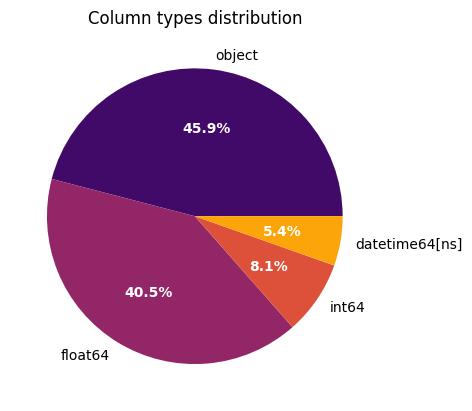

<Figure size 640x480 with 0 Axes>


Missing values after preprocessing:
SITE_CLASSIFICATION_EC8    27.27
LOCATION                   22.73


In [11]:
# Shape after preprocessing
print("Cleaned metadata shape:", df_meta_clean.shape)

# Column types distribution
print("\nColumn types distribution:")
print(df_meta_clean.dtypes.value_counts())

# Pie chart of column types
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    df_meta_clean.dtypes.astype(str).value_counts(),
    labels=df_meta_clean.dtypes.astype(str).value_counts().index,
    autopct='%1.1f%%',
    colors=colors
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title('Column types distribution')
plt.show()
plt.savefig('../figures/column_types_distribution.pdf', bbox_inches='tight')
plt.show()

# Missing values after preprocessing
print("\nMissing values after preprocessing:")
missing = df_meta_clean.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2).to_string())

In [13]:
# Numerical columns
print("Numerical columns:")
print(df_meta_clean.select_dtypes(include=['float64', 'int64']).columns.tolist())

Numerical columns:
['EVENT_LATITUDE_DEGREE', 'EVENT_LONGITUDE_DEGREE', 'EVENT_DEPTH_KM', 'MAGNITUDE_W', 'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'SAMPLING_INTERVAL_S', 'NDATA', 'DURATION_S', 'PGA_CM/S^2', 'TIME_PGA_S', 'FILTER_ORDER', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ']


In [14]:
# Categorical columns
print("Categorical columns:")
print(df_meta_clean.select_dtypes(include='object').columns.tolist())

Categorical columns:
['file', 'EVENT_ID', 'HYPOCENTER_REFERENCE', 'MAGNITUDE_W_REFERENCE', 'FOCAL_MECHANISM', 'NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION', 'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT', 'INSTRUMENT_ANALOG/DIGITAL', 'BASELINE_CORRECTION', 'FILTER_TYPE', 'LATE/NORMAL_TRIGGERED', 'PROCESSING']


# 6. Metadata Exploration (post-preprocessing)

In [15]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
print("Constant columns:", constant_cols)

Constant columns: ['EVENT_ID', 'EVENT_LATITUDE_DEGREE', 'EVENT_LONGITUDE_DEGREE', 'EVENT_DEPTH_KM', 'HYPOCENTER_REFERENCE', 'MAGNITUDE_W', 'MAGNITUDE_W_REFERENCE', 'FOCAL_MECHANISM', 'SAMPLING_INTERVAL_S', 'INSTRUMENT_ANALOG/DIGITAL', 'BASELINE_CORRECTION', 'FILTER_TYPE', 'FILTER_ORDER', 'LATE/NORMAL_TRIGGERED', 'PROCESSING', 'EVENT_DATE']


Since the dataset contains recordings from a single seismic event, many columns are constant across all files (e.g. event coordinates, magnitude, focal mechanism).  We create a reduced dataframe with only the varying columns, useful for analysis and visualization.

In [35]:
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
df_meta_var = df_meta_clean.drop(columns=constant_cols)
print(df_meta_var.columns.tolist())
df_meta_var = df_meta_var.copy()
df_meta_var['PGA_CM/S^2'] = df_meta_var['PGA_CM/S^2'].abs()

['file', 'NETWORK', 'STATION_CODE', 'STATION_NAME', 'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'LOCATION', 'SENSOR_DEPTH_M', 'SITE_CLASSIFICATION_EC8', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'NDATA', 'DURATION_S', 'STREAM', 'INSTRUMENT', 'PGA_CM/S^2', 'TIME_PGA_S', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ', 'DATE_TIME_FIRST_SAMPLE']


## Numerical and caterogical columns distributions

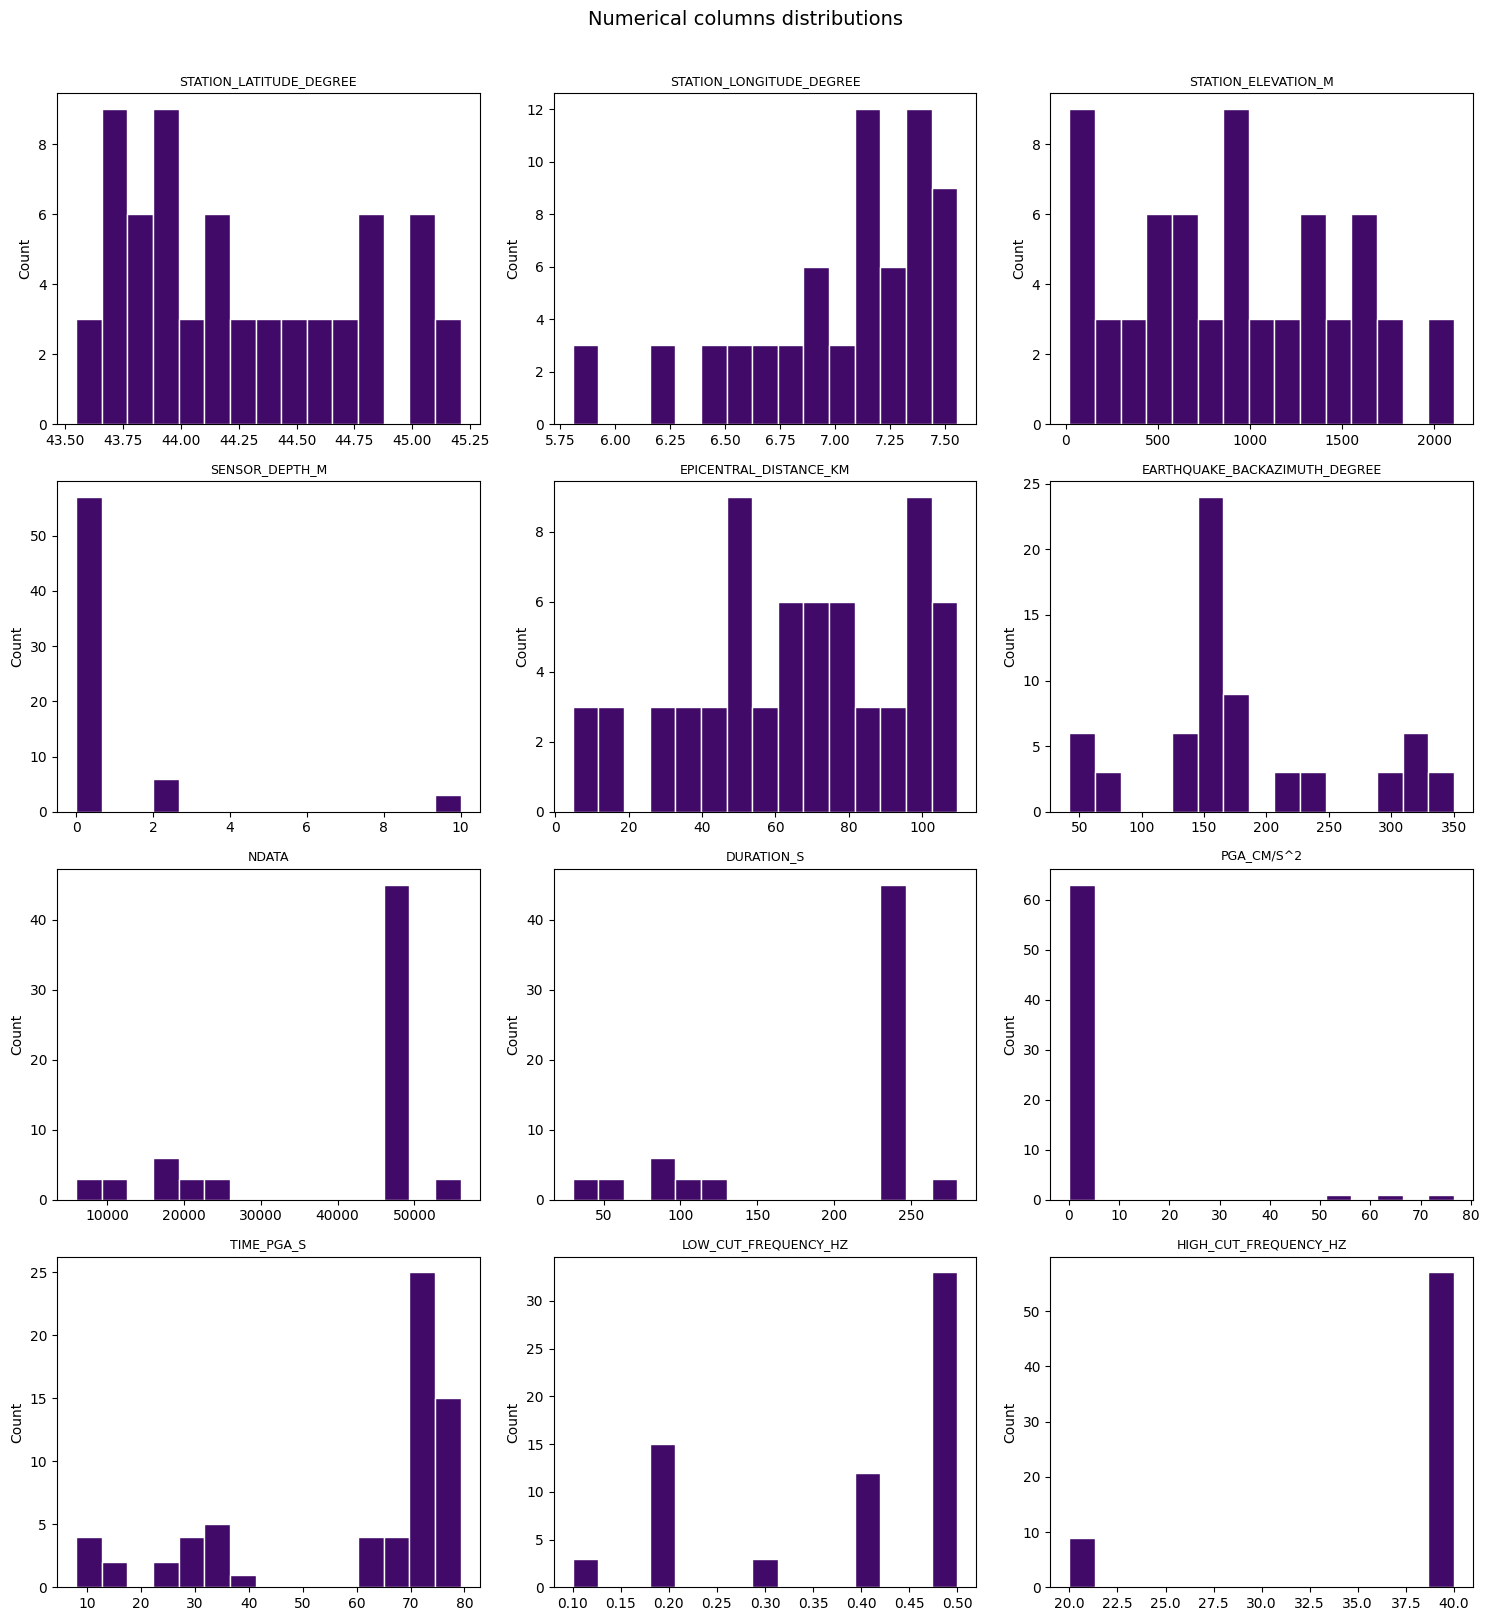

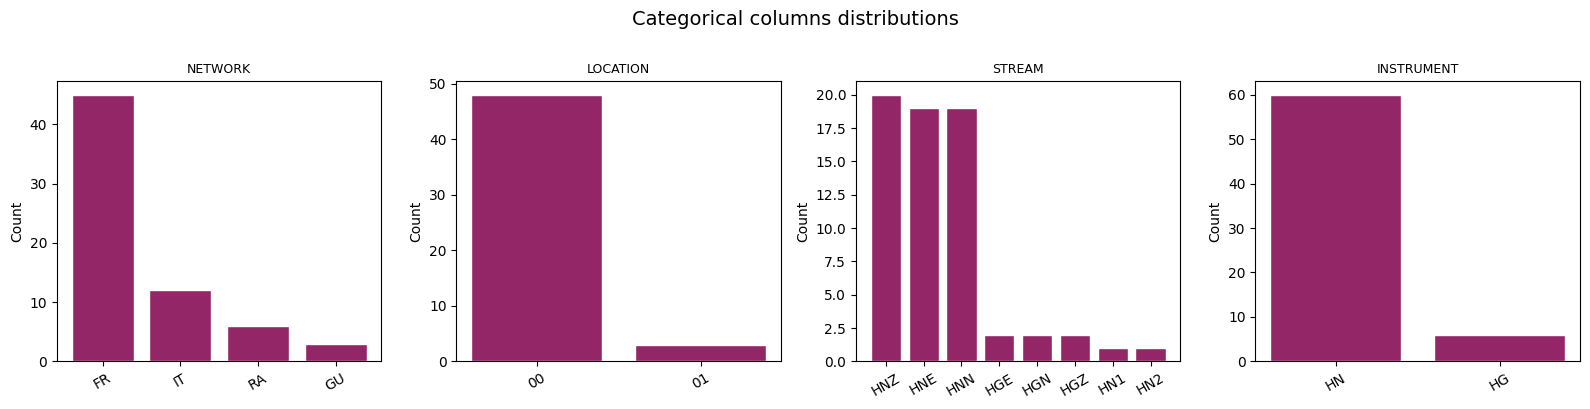

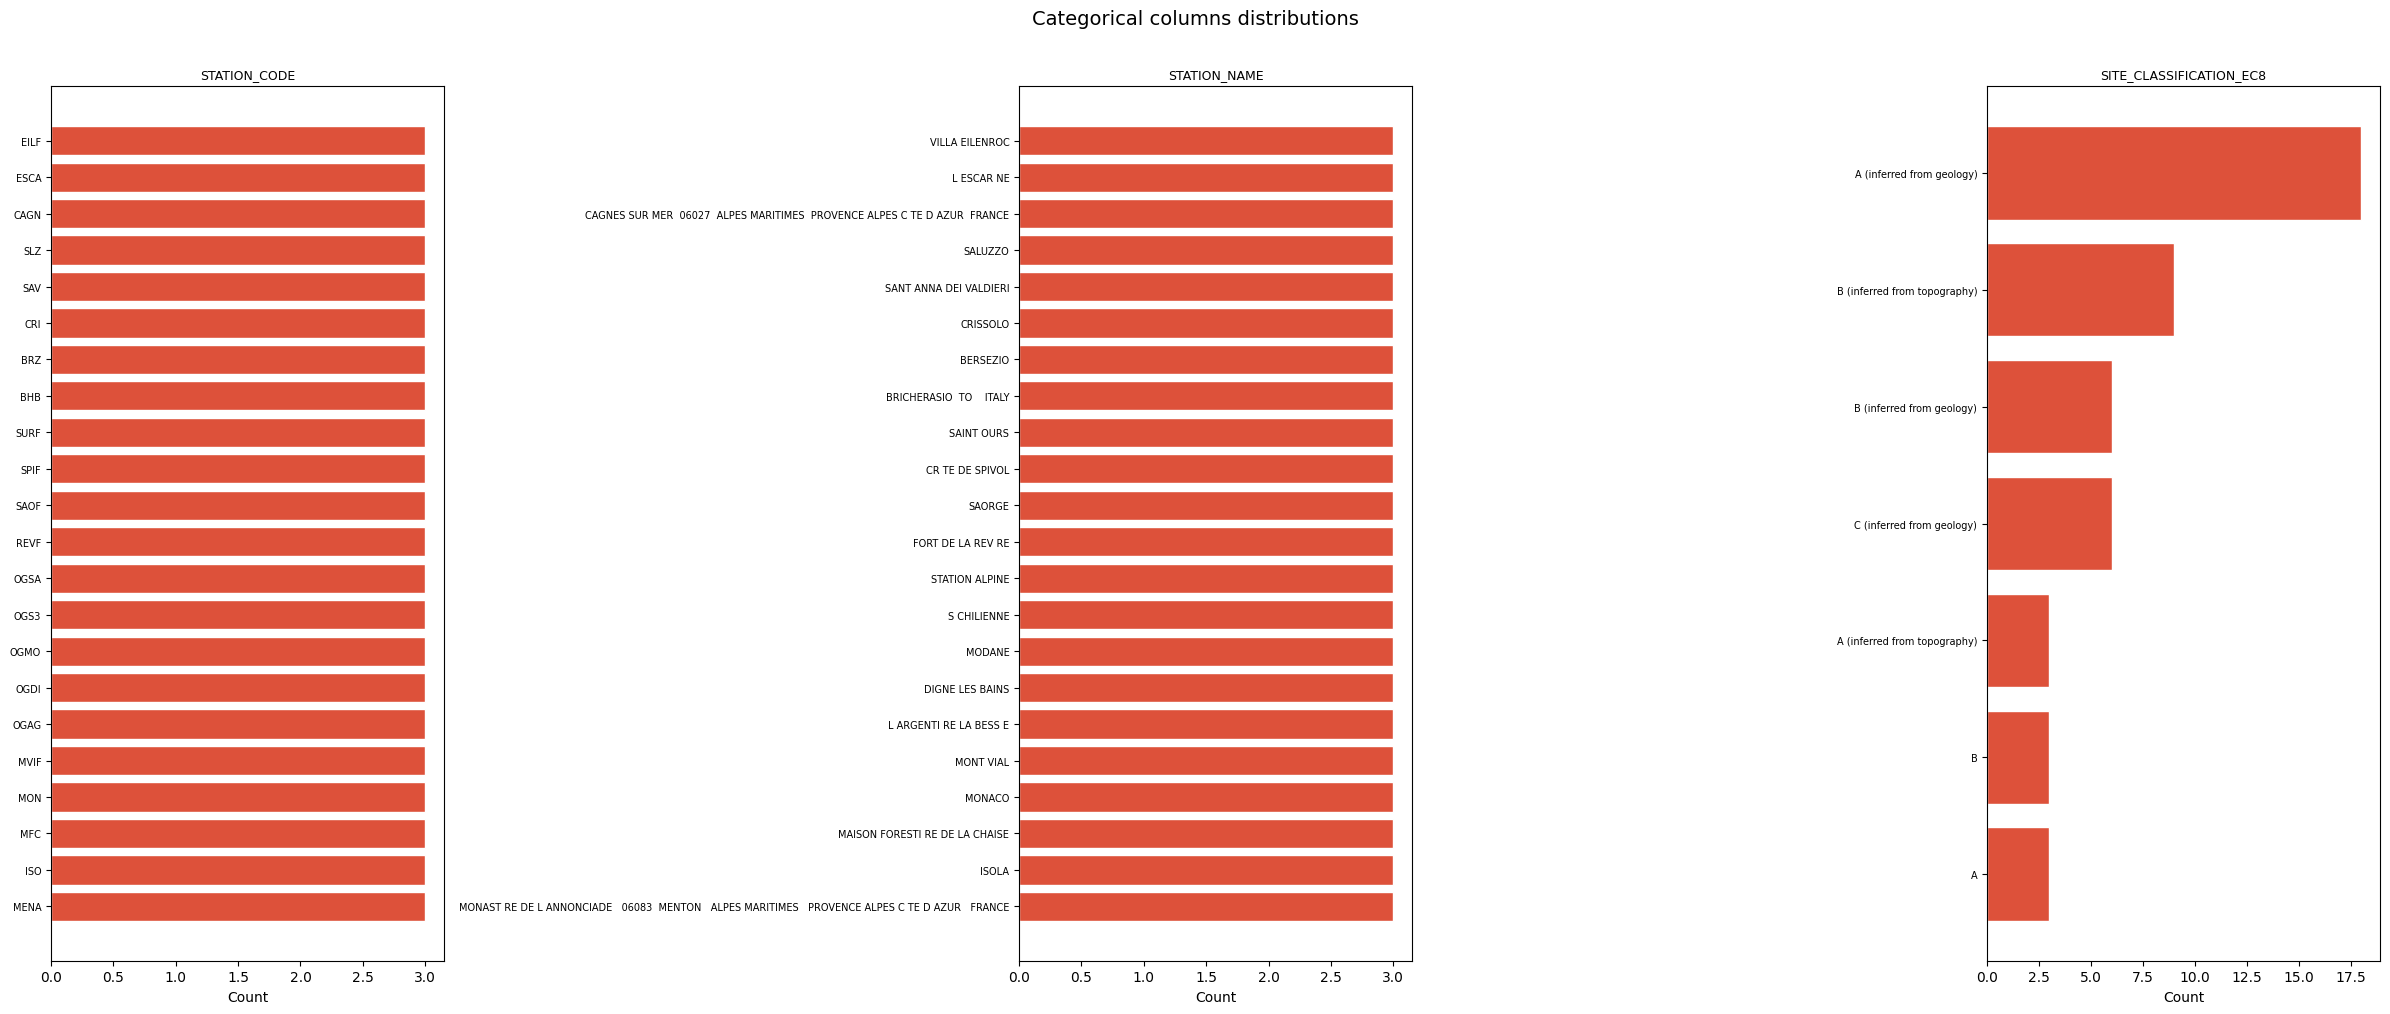

In [36]:
# ----------------
# NUMERICAL COLUMNS
# ----------------
num_cols = [
    'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M',
    'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE',
    'NDATA', 'DURATION_S', 'PGA_CM/S^2', 'TIME_PGA_S',
    'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_meta_var[col].dropna(), bins=15, color=colors[0], edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical columns distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/numerical_distributions.pdf', bbox_inches='tight')
plt.show()

# ----------------
# CATEGORICAL COLUMNS
# ----------------
cat_cols = ['NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION',
            'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT']

# Separate by number of unique values
few_cats = [c for c in cat_cols if df_meta_var[c].nunique() <= 8 and df_meta_var[c].str.len().max() <= 10]
many_cats = [c for c in cat_cols if df_meta_var[c].nunique() > 8 or df_meta_var[c].str.len().max() > 10]

# Bar chart vertical for few categories
fig, axes = plt.subplots(1, len(few_cats), figsize=(4 * len(few_cats), 4))
if len(few_cats) == 1:
    axes = [axes]
for i, col in enumerate(few_cats):
    counts = df_meta_var[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[1], edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')
    if df_meta_var[col].str.len().max() > 10:
        axes[i].tick_params(axis='x', rotation=45, labelsize=6)
    else:
        axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical columns distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/categorical_distributions_few.pdf', bbox_inches='tight')
plt.show()

# Bar chart horizontal for many categories
fig, axes = plt.subplots(1, len(many_cats), figsize=(8 * len(many_cats), 10))
if len(many_cats) == 1:
    axes = [axes]
for i, col in enumerate(many_cats):
    counts = df_meta_var[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=colors[2], edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Count')
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].invert_yaxis()

plt.suptitle('Categorical columns distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/categorical_distributions_many.pdf', bbox_inches='tight')
plt.show()

## Correlation matrix

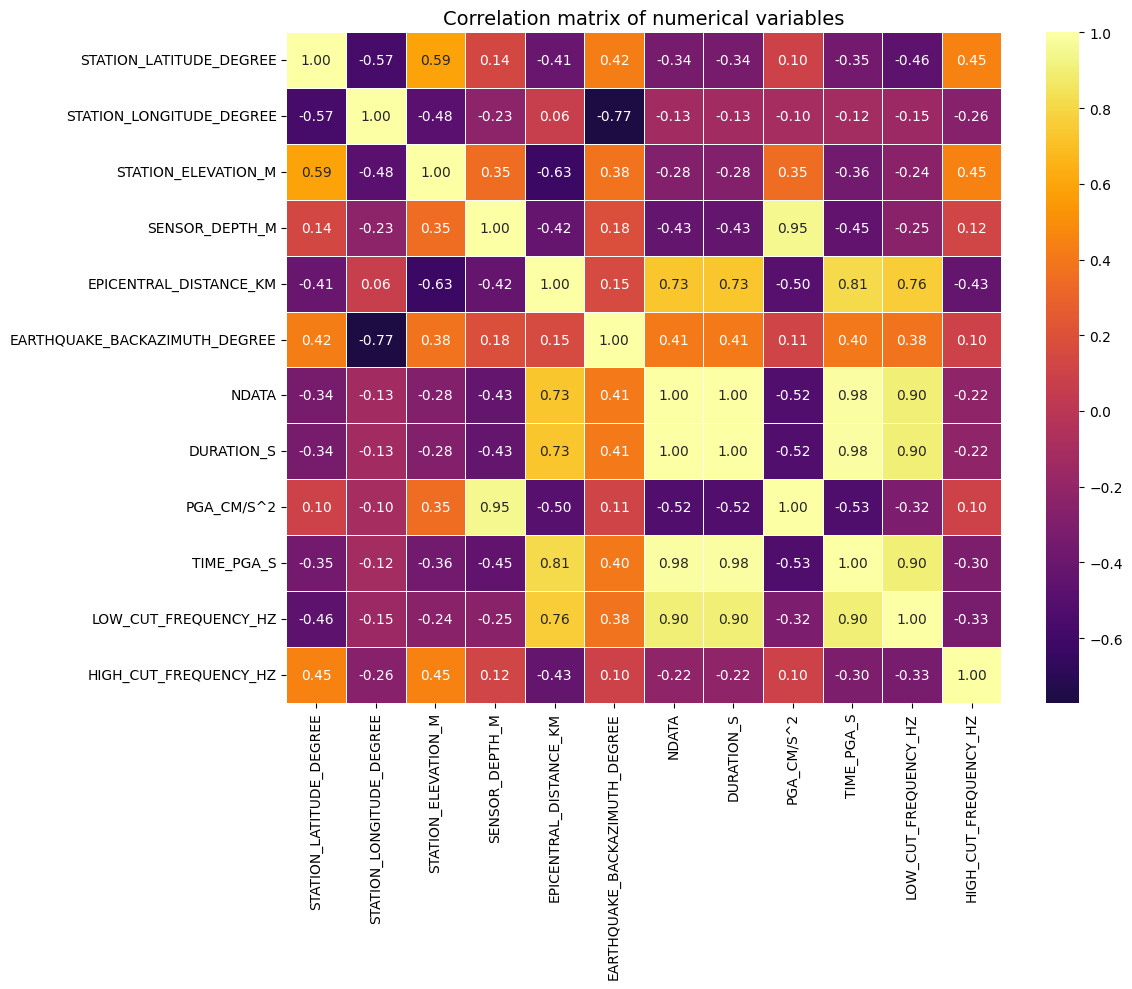

In [ ]:
corr = df_meta_var.select_dtypes(include=['float64', 'int64']).corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='inferno',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)
ax.set_title('Correlation matrix of numerical variables', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.pdf', bbox_inches='tight')
plt.show()

## Station map

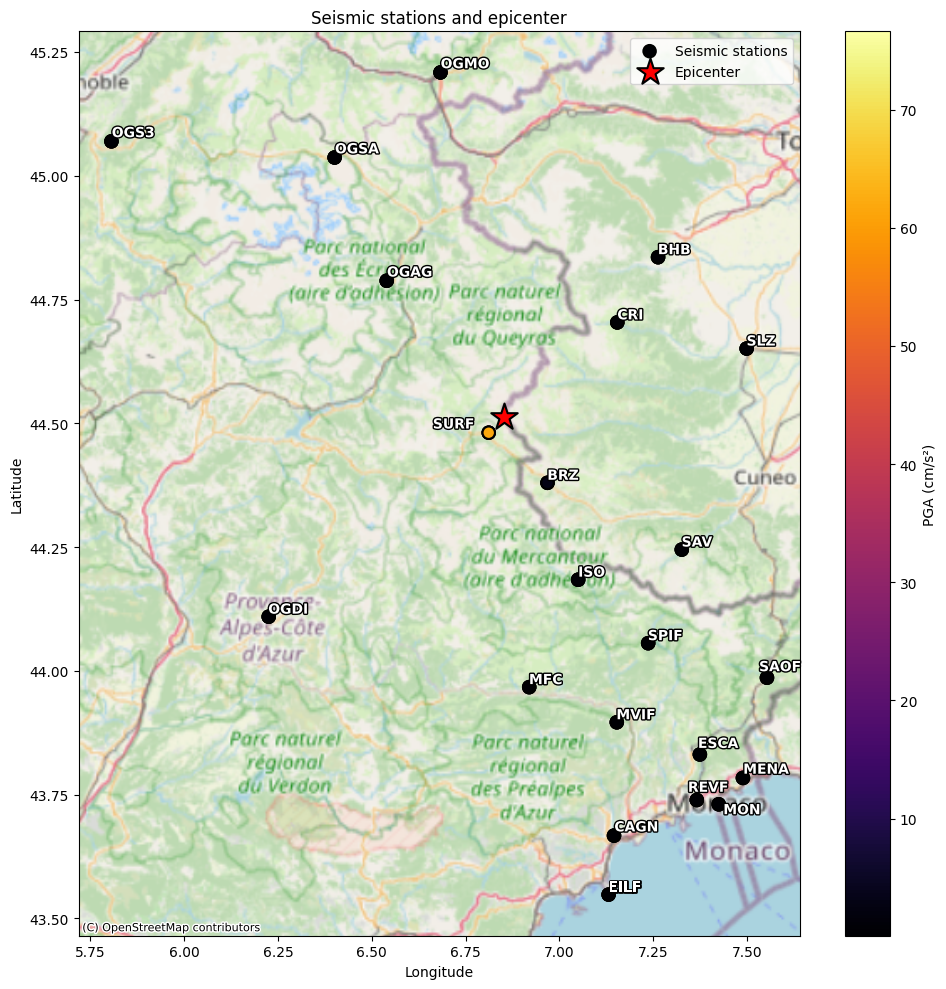

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot stations colored by PGA
scatter = ax.scatter(
    df_meta_var['STATION_LONGITUDE_DEGREE'],
    df_meta_var['STATION_LATITUDE_DEGREE'],
    c=df_meta_var['PGA_CM/S^2'],
    cmap='inferno',
    s=80,
    zorder=5,
    label='Seismic stations',
    edgecolors='black',
    linewidths=1.5
)

# Add station labels with adjustText
texts = []
for _, row in df_meta_var.drop_duplicates('STATION_CODE').iterrows():
    # Manual offset for SURF
    if row['STATION_CODE'] == 'SURF':
        x_offset = row['STATION_LONGITUDE_DEGREE'] - 0.15
        y_offset = row['STATION_LATITUDE_DEGREE']
    else:
        x_offset = row['STATION_LONGITUDE_DEGREE']
        y_offset = row['STATION_LATITUDE_DEGREE']
    
    texts.append(ax.text(
        x_offset,
        y_offset,
        row['STATION_CODE'],
        fontsize=10,
        color='white',
        fontweight='bold',
        path_effects=[
            plt.matplotlib.patheffects.withStroke(linewidth=2, foreground='black')
        ],
        zorder=6
    ))

adjust_text(texts, ax=ax, expand_points=(1.5, 1.5), expand_text=(1.5, 1.5))

# Plot epicenter
event_lat = df_meta_clean['EVENT_LATITUDE_DEGREE'].iloc[0]
event_lon = df_meta_clean['EVENT_LONGITUDE_DEGREE'].iloc[0]
ax.scatter(event_lon, event_lat, marker='*', color='red', s=400, zorder=7,
           label='Epicenter', edgecolors='black', linewidths=1.5)

# Add basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, zoom=8)

# Colorbar
plt.colorbar(scatter, ax=ax, label='PGA (cm/s²)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Seismic stations and epicenter')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/station_map.pdf', bbox_inches='tight')
plt.show()

## PGA analysis

/var/folders/w_/v957zs393c5dg1q6n0kpt_pr0000gn/T/ipykernel_3069/4171584243.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(stream_data, labels=streams, patch_artist=True)


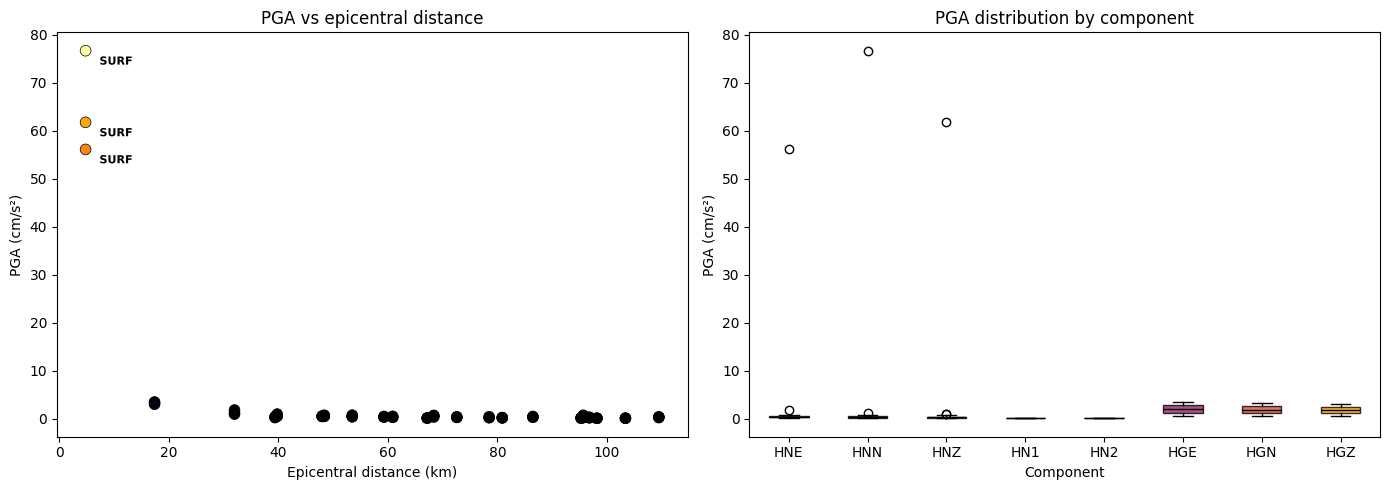

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. PGA vs epicentral distance
scatter = axes[0].scatter(
    df_meta_var['EPICENTRAL_DISTANCE_KM'],
    df_meta_var['PGA_CM/S^2'],
    c=df_meta_var['PGA_CM/S^2'],
    cmap='inferno',
    edgecolors='black',
    linewidths=0.5,
    s=60,
    zorder=5
)
axes[0].set_xlabel('Epicentral distance (km)')
axes[0].set_ylabel('PGA (cm/s²)')
axes[0].set_title('PGA vs epicentral distance')

# Annotate SURF
surf = df_meta_var[df_meta_var['STATION_CODE'] == 'SURF']
for _, row in surf.iterrows():
    axes[0].annotate(
        'SURF',
        (row['EPICENTRAL_DISTANCE_KM'], row['PGA_CM/S^2']),
        xytext=(10, -10),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=2, foreground='white')]
    )

# 2. PGA by component (STREAM)
streams = df_meta_var['STREAM'].unique()
stream_data = [df_meta_var[df_meta_var['STREAM'] == s]['PGA_CM/S^2'].dropna().values for s in streams]

bp = axes[1].boxplot(stream_data, labels=streams, patch_artist=True)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.8)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[element]:
        item.set_color('black')

axes[1].set_xlabel('Component')
axes[1].set_ylabel('PGA (cm/s²)')
axes[1].set_title('PGA distribution by component')

plt.tight_layout()
plt.savefig('../figures/pga_analysis.pdf', bbox_inches='tight')
plt.show()

# 7. Acceleration signals exploration

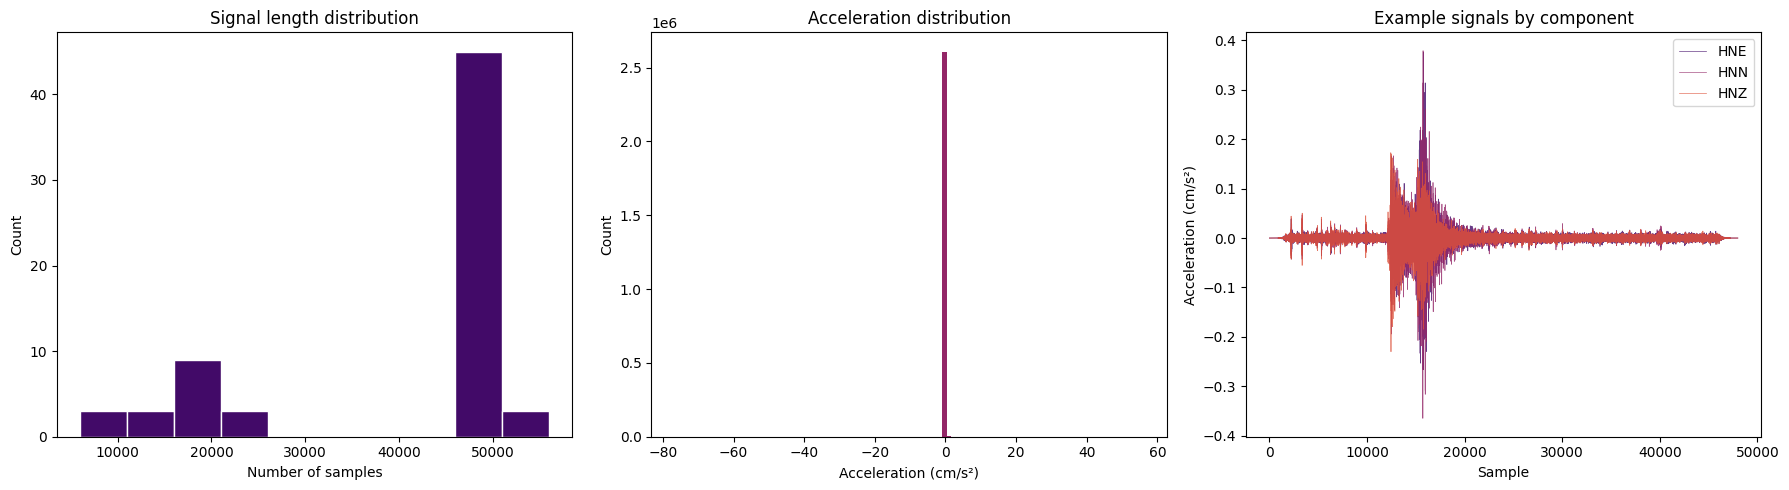

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of signal lengths
signal_lengths = df_acc.groupby('file')['sample'].max() + 1
axes[0].hist(signal_lengths, bins=10, color=colors[0], edgecolor='white')
axes[0].set_title('Signal length distribution')
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Count')

# 2. Distribution of acceleration values
axes[1].hist(df_acc['acceleration'], bins=100, color=colors[1], edgecolor='none')
axes[1].set_title('Acceleration distribution')
axes[1].set_xlabel('Acceleration (cm/s²)')
axes[1].set_ylabel('Count')

# 3. Example signal per component
for i, stream in enumerate(['HNE', 'HNN', 'HNZ']):
    example_file = df_meta_clean[df_meta_clean['STREAM'] == stream]['file'].iloc[0]
    signal = df_acc[df_acc['file'] == example_file]
    axes[2].plot(signal['sample'], signal['acceleration'], 
                 label=stream, color=colors[i], alpha=0.8, linewidth=0.5)

axes[2].set_title('Example signals by component')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('Acceleration (cm/s²)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../figures/acceleration_exploration.pdf', bbox_inches='tight')
plt.show()

# 8. Acceleration signals preprocessing

# 9. Post-preprocessing check (signals)